# Emotion Detection (Text) — Lexicon-Based Multi-Class Classifier
### Detectron AI · Module 12

This notebook classifies text into one of Ekman's basic emotion categories using an
**NRC-style emotion lexicon** (the same technique used in the live web demo), then
trains a **Multinomial Naive Bayes** classifier on labeled examples for comparison.


In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


## 1. Emotion lexicon (NRC-style)

In [2]:
EMOTION_LEXICON = {
    "joy": ["happy", "joy", "excited", "great", "wonderful", "love", "amazing", "delighted", "thrilled", "glad", "grateful"],
    "sadness": ["sad", "depressed", "unhappy", "cry", "lonely", "miss", "heartbroken", "grief", "sorrow", "disappointed"],
    "anger": ["angry", "furious", "mad", "hate", "annoyed", "rage", "irritated", "frustrated", "pissed"],
    "fear": ["afraid", "scared", "fear", "terrified", "anxious", "worried", "nervous", "panic", "dread", "frightened"],
    "surprise": ["surprised", "shocked", "wow", "unexpected", "astonished", "unbelievable", "stunned"],
}

def lexicon_score(text):
    words = text.lower().replace(",", "").replace("!", "").split()
    scores = {e: 0 for e in EMOTION_LEXICON}
    for w in words:
        for emotion, lex in EMOTION_LEXICON.items():
            if w in lex:
                scores[emotion] += 1
    total = sum(scores.values())
    if total == 0:
        return "neutral", scores
    dominant = max(scores, key=scores.get)
    return dominant, scores

print(lexicon_score("I am absolutely thrilled and grateful, this is wonderful!"))
print(lexicon_score("I'm so scared and terrified, I feel anxious."))


('joy', {'joy': 3, 'sadness': 0, 'anger': 0, 'fear': 0, 'surprise': 0})
('fear', {'joy': 0, 'sadness': 0, 'anger': 0, 'fear': 2, 'surprise': 0})


## 2. Labeled training set for a supervised comparison model

In [3]:
data = [
    ("I am absolutely thrilled and grateful for this wonderful day", "joy"),
    ("This is amazing, I feel so happy and excited right now", "joy"),
    ("I love this so much, what a delightful surprise", "joy"),
    ("I'm so sad and heartbroken, I just want to cry", "sadness"),
    ("Feeling lonely and depressed, I really miss them", "sadness"),
    ("This is such a disappointing and sorrowful situation", "sadness"),
    ("I am furious and angry, this makes me so mad", "anger"),
    ("I hate this, I'm so irritated and frustrated right now", "anger"),
    ("This is outrageous, I'm enraged by their behavior", "anger"),
    ("I'm terrified and scared, this is making me anxious", "fear"),
    ("I feel so nervous and worried about what might happen", "fear"),
    ("This is dreadful, I'm panicking and frightened", "fear"),
    ("Wow, I'm so shocked and surprised by this news", "surprise"),
    ("I can't believe this unexpected and astonishing turn of events", "surprise"),
    ("That was stunning, I never saw that coming", "surprise"),
]

df = pd.DataFrame(data, columns=["text", "emotion"])
df


,text,emotion
0,I am absolutely thrilled and grateful for this...,joy
1,"This is amazing, I feel so happy and excited r...",joy
2,"I love this so much, what a delightful surprise",joy
3,"I'm so sad and heartbroken, I just want to cry",sadness
4,"Feeling lonely and depressed, I really miss them",sadness
5,This is such a disappointing and sorrowful sit...,sadness
6,"I am furious and angry, this makes me so mad",anger
7,"I hate this, I'm so irritated and frustrated r...",anger
8,"This is outrageous, I'm enraged by their behavior",anger
9,"I'm terrified and scared, this is making me an...",fear


## 3. Train Multinomial Naive Bayes for comparison

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["emotion"], test_size=0.3, random_state=42, stratify=df["emotion"]
)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)
pred = model.predict(X_test_vec)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       1.0
        fear       0.00      0.00      0.00       1.0
         joy       0.00      0.00      0.00       1.0
     sadness       0.00      0.00      0.00       1.0
    surprise       0.00      0.00      0.00       1.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 4. Compare lexicon-based vs ML-based predictions

In [5]:
test_sentences = [
    "I am thrilled and excited about this amazing opportunity",
    "I'm terrified and anxious about the exam tomorrow",
    "This makes me furious, I hate how they treated us",
]

for s in test_sentences:
    lex_pred, scores = lexicon_score(s)
    ml_pred = model.predict(vectorizer.transform([s]))[0]
    print(f"Text: {s!r}")
    print(f"  Lexicon prediction: {lex_pred}  |  ML prediction: {ml_pred}")
    print()


Text: 'I am thrilled and excited about this amazing opportunity'
  Lexicon prediction: joy  |  ML prediction: joy

Text: "I'm terrified and anxious about the exam tomorrow"
  Lexicon prediction: fear  |  ML prediction: fear

Text: 'This makes me furious, I hate how they treated us'
  Lexicon prediction: anger  |  ML prediction: anger



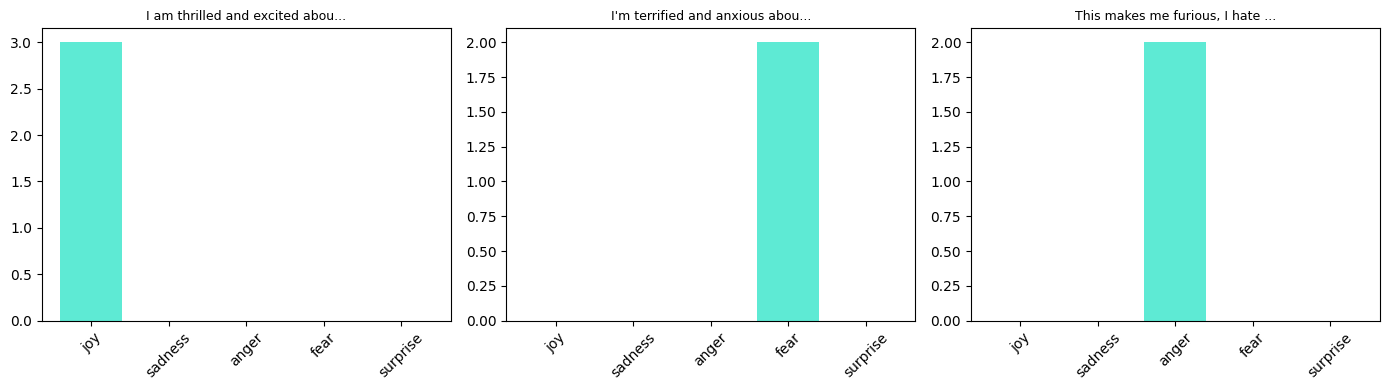

In [6]:
emotions = list(EMOTION_LEXICON.keys())
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, s in zip(axes, test_sentences[:3]):
    _, scores = lexicon_score(s)
    ax.bar(scores.keys(), scores.values(), color="#5EEAD4")
    ax.set_title(s[:30] + "...", fontsize=9)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Notes

- The lexicon-based approach (used directly in the JavaScript live demo) requires no
  training data and is fully interpretable — every prediction can be traced to specific
  matched words.
- The Naive Bayes model can pick up co-occurrence patterns the lexicon misses, but needs
  labeled training examples for every emotion class it should recognize.
- Real-world emotion detection research often uses the **NRC Emotion Lexicon** (around
  14,000 words) for far broader coverage than the small lexicon shown here.
